# Robustness Visualization

In [1]:
import sys
import os
import toml

In [2]:
from scipy.special import rel_entr
from torch.utils.data import DataLoader
from tqdm.auto import tqdm
import numpy as np
import polars as pl
import torch
import torch.nn.functional as F
from ipywidgets import interactive, IntSlider
from IPython.display import display

import matplotlib.pyplot as plt
import matplotlib.patches as mpatches

In [3]:
# plt.rcParams["text.usetex"] = True
# plt.rcParams["text.latex.preamble"] = r'\usepackage{amsmath}\usepackage{amssymb}'
# plt.rcParams["font.family"] = r'serif'
# plt.rcParams["font.serif"] = r'Computer Modern'

golden_ratio = (1 + 5 ** 0.5) / 2
cm_to_in = 1/2.54  # centimeters in inches
width = 8.45 * cm_to_in
height = width / golden_ratio

In [4]:
sys.path.append('..')

from axe.lcm.data.schema import LCMDataSchema
from axe.lcm.model import LCMWrapper
from axe.lcm.model.builder import LearnedCostModelBuilder
from axe.lsm.cost import Cost
from axe.lsm.types import Policy, LSMBounds, LSMDesign, System, Workload
from axe.ltuner.data.schema import LTunerDataSchema
from axe.ltuner.model.builder import LTuneModelBuilder
import axe.lsm.solver as Solvers

In [5]:
from axe.classic_lcm_solver import ClassicLCMSolver

In [6]:
model_path = '../data/ltuner/models/rcsampler_112624_1131/'
model_override_code = 'RobustClassicTunerSampler'
cfg = toml.load(os.path.join(model_path, 'axe.toml'))
cfg["job"]["use_gpu_if_avail"] = False

In [7]:
bounds = LSMBounds(**cfg["lsm"]["bounds"])
policy = getattr(Policy, cfg["lsm"]["policy"])
categories = bounds.size_ratio_range[1] - bounds.size_ratio_range[0]
cost_fn = Cost(bounds.max_considered_levels)

In [8]:
lcm_cfg = toml.load('../data/lcm/models/classic_lcm_111324_1927/axe.toml')
lcm_bounds = LSMBounds(**lcm_cfg["lsm"]["bounds"])
lcm_policy = getattr(Policy, lcm_cfg["lsm"]["policy"])
lcm_schema = LCMDataSchema(lcm_policy, lcm_bounds)

In [9]:
lcm = LearnedCostModelBuilder(
    schema=lcm_schema, **lcm_cfg['lcm']['model']
).build(disable_one_hot_encoding=True)
lcm.eval()
lcm_weights = torch.load('../data/lcm/models/classic_lcm_111324_1927/best_model.model', weights_only=True)
status = lcm.load_state_dict(lcm_weights['model_state_dict'])
status, lcm

(<All keys matched successfully>,
 ClassicLCM(
   (t_embedding): Linear(in_features=20, out_features=8, bias=True)
   (policy_embedding): Linear(in_features=2, out_features=4, bias=True)
   (in_norm): BatchNorm1d(22, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
   (in_layer): Linear(in_features=22, out_features=32, bias=True)
   (relu): ReLU(inplace=True)
   (dropout): Dropout(p=0.0, inplace=False)
   (hidden): Sequential(
     (0): Linear(in_features=32, out_features=32, bias=True)
     (1): ReLU(inplace=True)
   )
   (out_layer): Linear(in_features=32, out_features=32, bias=True)
   (z0): Linear(in_features=8, out_features=1, bias=True)
   (z1): Linear(in_features=8, out_features=1, bias=True)
   (q): Linear(in_features=8, out_features=1, bias=True)
   (w): Linear(in_features=8, out_features=1, bias=True)
 ))

In [10]:
lcm_wrap = LCMWrapper(lcm, lcm_schema)
lcm_solver = ClassicLCMSolver(lcm_bounds, lcm_wrap)

In [11]:
def kl_div(wlx: Workload, wly: Workload):
    wlx = np.array([wlx.z0, wlx.z1, wlx.q, wlx.w])
    wly = np.array([wly.z0, wly.z1, wly.q, wly.w])
    return np.sum(rel_entr(wlx, wly))

## Testing Data

For now lets say all testing data generated by seed=0

In [12]:
def row_to_obj(row):
    workload = Workload(row['z0'], row['z1'], row['q'], row['w'])
    system = System(entries_per_page=row['entry_p_page'], selectivity=row['selec'],
                    entry_size=row['entry_size'], mem_budget=row['mem_budget'],
                    num_entries=row['num_elem'])
    return workload, system

In [13]:
expected_workloads = (
    Workload(z0=0.25, z1=0.25, q=0.25, w=0.25), # 00
    Workload(z0=0.97, z1=0.01, q=0.01, w=0.01), # 01
    Workload(z0=0.01, z1=0.97, q=0.01, w=0.01), # 02
    Workload(z0=0.01, z1=0.01, q=0.97, w=0.01), # 03
    Workload(z0=0.01, z1=0.01, q=0.01, w=0.97), # 04
    Workload(z0=0.49, z1=0.49, q=0.01, w=0.01), # 01
    Workload(z0=0.49, z1=0.01, q=0.49, w=0.01), # 06
    Workload(z0=0.49, z1=0.01, q=0.01, w=0.49), # 07
    Workload(z0=0.01, z1=0.49, q=0.49, w=0.01), # 08
    Workload(z0=0.01, z1=0.49, q=0.01, w=0.49), # 09
    Workload(z0=0.01, z1=0.01, q=0.49, w=0.49), # 10
    Workload(z0=0.33, z1=0.33, q=0.33, w=0.01), # 11
    Workload(z0=0.33, z1=0.33, q=0.01, w=0.33), # 12
    Workload(z0=0.33, z1=0.01, q=0.33, w=0.33), # 13
    Workload(z0=0.01, z1=0.33, q=0.33, w=0.33), # 14
)
# default_sys = System(num_entries=1e7, selectivity=0)
default_sys = System(num_entries=1e7)
# default_sys = System()

In [14]:
SEED = 0
NUM_SAMPLES = 1000

In [15]:
schema = LTunerDataSchema(policy=policy, bounds=bounds, seed=SEED, robust=True)
bench_table = []
for _ in tqdm(range(NUM_SAMPLES)):
    row = schema.sample_row_dict()
    row['entry_p_page'] = default_sys.entries_per_page
    row['selec'] = default_sys.selectivity
    row['entry_size'] = default_sys.entry_size
    row['mem_budget'] = default_sys.mem_budget
    row['num_elem'] = default_sys.num_entries
    bench_table.append(row)
bench_table = pl.DataFrame(bench_table).drop('rho')
bench_table

  0%|          | 0/1000 [00:00<?, ?it/s]

z0,z1,q,w,entry_p_page,selec,entry_size,mem_budget,num_elem
f64,f64,f64,f64,i64,f64,i64,f64,f64
0.041,0.229,0.367,0.363,4,0.0000004,8192,10.0,1e7
0.544,0.272,0.119,0.065,4,0.0000004,8192,10.0,1e7
0.3,0.241,0.322,0.137,4,0.0000004,8192,10.0,1e7
0.384,0.231,0.032,0.353,4,0.0000004,8192,10.0,1e7
0.135,0.254,0.332,0.279,4,0.0000004,8192,10.0,1e7
…,…,…,…,…,…,…,…,…
0.705,0.066,0.196,0.033,4,0.0000004,8192,10.0,1e7
0.531,0.018,0.437,0.014,4,0.0000004,8192,10.0,1e7
0.884,0.016,0.032,0.068,4,0.0000004,8192,10.0,1e7


In [16]:
input_table = []
for wl_id, wl in enumerate(expected_workloads):
    for rho in [0, 0.25, 0.5, 0.75, 1, 1.25, 1.5, 1.75, 2]:
        row = {'wl_id': wl_id, 'rho': rho, 'z0': wl.z0, 'z1': wl.z1, 'q': wl.q, 'w': wl.w, 'entry_p_page': default_sys.entries_per_page,
               'selec': default_sys.selectivity, 'entry_size': default_sys.entry_size,
               'mem_budget': default_sys.mem_budget, 'num_elem': default_sys.num_entries}
        input_table.append(row)
input_table = pl.DataFrame(input_table)
input_table

wl_id,rho,z0,z1,q,w,entry_p_page,selec,entry_size,mem_budget,num_elem
i64,f64,f64,f64,f64,f64,i64,f64,i64,f64,f64
0,0.0,0.25,0.25,0.25,0.25,4,0.0000004,8192,10.0,1e7
0,0.25,0.25,0.25,0.25,0.25,4,0.0000004,8192,10.0,1e7
0,0.5,0.25,0.25,0.25,0.25,4,0.0000004,8192,10.0,1e7
0,0.75,0.25,0.25,0.25,0.25,4,0.0000004,8192,10.0,1e7
0,1.0,0.25,0.25,0.25,0.25,4,0.0000004,8192,10.0,1e7
…,…,…,…,…,…,…,…,…,…,…
14,1.0,0.01,0.33,0.33,0.33,4,0.0000004,8192,10.0,1e7
14,1.25,0.01,0.33,0.33,0.33,4,0.0000004,8192,10.0,1e7
14,1.5,0.01,0.33,0.33,0.33,4,0.0000004,8192,10.0,1e7


In [17]:
input_dataset = input_table.to_torch(
    return_type="dataset",
    features=schema.feat_cols(),
    label=schema.label_cols(),
    dtype=pl.Float32
)

## Build Model

In [18]:
ltuner = LTuneModelBuilder(
    schema=schema,
    **cfg['ltuner']['model']
).build(robust=True, override=model_override_code)
ltuner_weights = torch.load(
    os.path.join(model_path, 'best_model.model'),
    weights_only=True,
    map_location=torch.device('cpu')
)
status = ltuner.load_state_dict(ltuner_weights['model_state_dict'])
ltuner.eval()
ltuner, status

(RobustClassicTunerSampler(
   (in_norm): BatchNorm1d(10, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
   (in_layer): Linear(in_features=10, out_features=64, bias=True)
   (relu): ReLU()
   (dropout): Dropout(p=0, inplace=False)
   (hidden): Sequential(
     (0): Linear(in_features=64, out_features=64, bias=True)
     (1): Linear(in_features=64, out_features=64, bias=True)
     (2): Linear(in_features=64, out_features=64, bias=True)
   )
   (t_decision): Linear(in_features=64, out_features=20, bias=True)
   (bits_decision): Linear(in_features=64, out_features=1, bias=True)
   (policy_decision): Linear(in_features=64, out_features=2, bias=True)
   (lagrangian_mu): Linear(in_features=10, out_features=2, bias=True)
   (lagrangian_sigma): Linear(in_features=10, out_features=2, bias=True)
 ),
 <All keys matched successfully>)

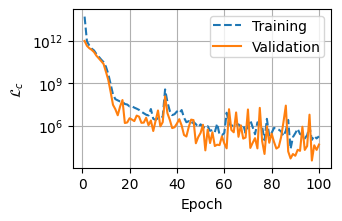

In [19]:
losses = pl.read_csv(os.path.join(model_path, 'losses.csv'))
# losses = losses.loc[0:]
fig, ax = plt.subplots(figsize=(width, height))
ax.plot(losses['epoch'], losses['train_loss'], label='Training', linestyle='--')
ax.plot(losses['epoch'], losses['test_loss'], label='Validation', linestyle='-')
ax.set_xlabel('Epoch')
ax.set_ylabel(r'$\mathcal{{L}}_c$')
ax.set_yscale('log')
ax.grid()
_ = ax.legend(loc='upper right', borderpad=0.2)

## Create Robust Tunings

In [20]:
def convert_ltune_out_to_design(out, schema):
    out = out.flatten()
    categories = schema.bounds.size_ratio_range[1] - schema.bounds.size_ratio_range[0]
    eta = out[0].item()
    lamb = out[1].item()
    bpe = out[2].item()
    size_ratio = out[3:3+categories].argmax().item() + schema.bounds.size_ratio_range[0]
    policy = out[-2:].argmax().item()
    
    return LSMDesign(bits_per_elem=bpe, size_ratio=size_ratio, policy=Policy(policy), kapacity=())

In [21]:
og_bounds = bounds
og_bounds.size_ratio_range = (2, 100)
solver = Solvers.ClassicSolver(og_bounds)

In [22]:
robust_tuner_designs = []
robust_lcm_tuner_designs = []
robust_solver_designs = []
nominal_solver_designs = []
for (feat, label) in tqdm(input_dataset, desc='Learned Tuner'):
    out = ltuner(feat.unsqueeze(0))
    design = convert_ltune_out_to_design(out, schema)
    robust_tuner_designs.append(design)
for row in tqdm(input_table.iter_rows(named=True), total=len(input_table), desc='Solver Tuner'):
    rho = row['rho']
    workload, system, = row_to_obj(row)
    design, _ = solver.get_nominal_design(system, workload)
    nominal_solver_designs.append(design)
    design, _ = solver.get_robust_design(system, workload, rho, init_args=[1, 1, design.bits_per_elem, design.size_ratio])
    robust_solver_designs.append(design)
    robust_lcm_design, _ = lcm_solver.get_robust_design(system, workload, rho, init_args=[1, 1, design.bits_per_elem, design.size_ratio])
    robust_lcm_tuner_designs.append(robust_lcm_design)
# robust_tuner_designs, robust_solver_designs

Learned Tuner:   0%|          | 0/135 [00:00<?, ?it/s]

Solver Tuner:   0%|          | 0/135 [00:00<?, ?it/s]

/home/ndhuynh/miniconda3/envs/axe/lib/python3.12/site-packages/scipy/optimize/_slsqp_py.py:434: RuntimeWarning: Values in x were outside bounds during a minimize step, clipping to bounds
  fx = wrapped_fun(x)
/home/ndhuynh/miniconda3/envs/axe/lib/python3.12/site-packages/scipy/optimize/_slsqp_py.py:438: RuntimeWarning: Values in x were outside bounds during a minimize step, clipping to bounds
  g = append(wrapped_grad(x), 0.0)
/home/ndhuynh/miniconda3/envs/axe/lib/python3.12/site-packages/scipy/optimize/_numdiff.py:592: RuntimeWarning: invalid value encountered in subtract
  df = fun(x1) - f0
/home/ndhuynh/repo/proj_axe/notebook/../axe/lsm/solver/util.py:19: RuntimeWarning: overflow encountered in exp
  return np.exp(input) - 1


In [23]:
df = []
for tuner_design, solver_design, nominal_design, robust_lcm_design in zip(robust_tuner_designs, robust_solver_designs, nominal_solver_designs, robust_lcm_tuner_designs):
    df.append({'tuner_design': tuner_design, 'solver_design': solver_design, 'nominal_design': nominal_design, 'solver_lcm_design': robust_lcm_design})
df = pl.DataFrame(df)
design_table = pl.concat((input_table, df), how='horizontal')
design_table.head(5)

wl_id,rho,z0,z1,q,w,entry_p_page,selec,entry_size,mem_budget,num_elem,tuner_design,solver_design,nominal_design,solver_lcm_design
i64,f64,f64,f64,f64,f64,i64,f64,i64,f64,f64,object,object,object,object
0,0.0,0.25,0.25,0.25,0.25,4,0.0000004,8192,10.0,1e7,"LSMDesign(bits_per_elem=6.677365779876709, size_ratio=4, policy=<Policy.Leveling: 1>, kapacity=())","LSMDesign(bits_per_elem=3.2077581958023074, size_ratio=5.80690042550729, policy=<Policy.Leveling: 1>, kapacity=())","LSMDesign(bits_per_elem=3.2110053495416655, size_ratio=5.808035229139304, policy=<Policy.Leveling: 1>, kapacity=())","LSMDesign(bits_per_elem=3.2077581958023074, size_ratio=5.80690042550729, policy=<Policy.Leveling: 1>, kapacity=())"
0,0.25,0.25,0.25,0.25,0.25,4,0.0000004,8192,10.0,1e7,"LSMDesign(bits_per_elem=6.763563632965088, size_ratio=4, policy=<Policy.Leveling: 1>, kapacity=())","LSMDesign(bits_per_elem=1.0, size_ratio=5.369583225542168, policy=<Policy.Leveling: 1>, kapacity=())","LSMDesign(bits_per_elem=3.2110053495416655, size_ratio=5.808035229139304, policy=<Policy.Leveling: 1>, kapacity=())","LSMDesign(bits_per_elem=1.0, size_ratio=5.369583225542168, policy=<Policy.Leveling: 1>, kapacity=())"
0,0.5,0.25,0.25,0.25,0.25,4,0.0000004,8192,10.0,1e7,"LSMDesign(bits_per_elem=6.854272842407227, size_ratio=4, policy=<Policy.Leveling: 1>, kapacity=())","LSMDesign(bits_per_elem=1.0000000000000004, size_ratio=5.213571549701873, policy=<Policy.Leveling: 1>, kapacity=())","LSMDesign(bits_per_elem=3.2110053495416655, size_ratio=5.808035229139304, policy=<Policy.Leveling: 1>, kapacity=())","LSMDesign(bits_per_elem=1.0000000000000004, size_ratio=5.213571549701873, policy=<Policy.Leveling: 1>, kapacity=())"
0,0.75,0.25,0.25,0.25,0.25,4,0.0000004,8192,10.0,1e7,"LSMDesign(bits_per_elem=6.944980144500732, size_ratio=4, policy=<Policy.Leveling: 1>, kapacity=())","LSMDesign(bits_per_elem=1.0, size_ratio=4.968113680864477, policy=<Policy.Leveling: 1>, kapacity=())","LSMDesign(bits_per_elem=3.2110053495416655, size_ratio=5.808035229139304, policy=<Policy.Leveling: 1>, kapacity=())","LSMDesign(bits_per_elem=1.0, size_ratio=4.968113680864477, policy=<Policy.Leveling: 1>, kapacity=())"
0,1.0,0.25,0.25,0.25,0.25,4,0.0000004,8192,10.0,1e7,"LSMDesign(bits_per_elem=7.035689830780029, size_ratio=4, policy=<Policy.Leveling: 1>, kapacity=())","LSMDesign(bits_per_elem=1.0000000000000002, size_ratio=4.968113717748069, policy=<Policy.Leveling: 1>, kapacity=())","LSMDesign(bits_per_elem=3.2110053495416655, size_ratio=5.808035229139304, policy=<Policy.Leveling: 1>, kapacity=())","LSMDesign(bits_per_elem=1.0000000000000002, size_ratio=4.968113717748069, policy=<Policy.Leveling: 1>, kapacity=())"


In [24]:
result_table = {'wl_id': [], 'rho': [], 'workload_0': [], 'workload_hat': [],
                'rho_hat': [], 'solver_cost': [], 'tuner_cost': [],
                'nominal_cost': [], 'solver_lcm_cost': []}
for design_row in tqdm(design_table.iter_rows(named=True), total=len(design_table)):
    workload0, _, = row_to_obj(design_row)
    wl_id, rho = design_row['wl_id'], design_row['rho']
    for bench_row in bench_table.iter_rows(named=True):
        workload_hat, _ = row_to_obj(bench_row)
        result_table['wl_id'].append(wl_id)
        result_table['rho'].append(rho)
        result_table['workload_0'].append(workload0)
        result_table['workload_hat'].append(workload_hat)
        result_table['rho_hat'].append(kl_div(workload_hat, workload0))
        result_table['solver_cost'].append(cost_fn.calc_cost(design_row['solver_design'], default_sys, workload_hat))
        ltuner_design = design_row['tuner_design']
        if ltuner_design.bits_per_elem > default_sys.mem_budget:
            ltuner_design.bits_per_elem = default_sys.mem_budget - 0.1
        result_table['tuner_cost'].append(cost_fn.calc_cost(ltuner_design, default_sys, workload_hat))
        result_table['nominal_cost'].append(cost_fn.calc_cost(design_row['nominal_design'], default_sys, workload_hat))
        result_table['solver_lcm_cost'].append(cost_fn.calc_cost(design_row['solver_lcm_design'], default_sys, workload_hat))
result_table = pl.DataFrame(result_table)

  0%|          | 0/135 [00:00<?, ?it/s]

In [25]:
result_table = result_table.with_columns(
    solver_throughput=1/pl.col('solver_cost'),
    tuner_throughput=1/pl.col('tuner_cost'),
    nominal_throughput=1/pl.col('nominal_cost'),
    solver_lcm_throughput=1/pl.col('solver_lcm_cost')
)
result_table = result_table.with_columns(
    delta_throughput=((pl.col('tuner_throughput') - pl.col('nominal_throughput')) / pl.col('nominal_throughput')),
    delta_throughput_solver=((pl.col('solver_throughput') - pl.col('nominal_throughput')) / pl.col('nominal_throughput')),
    delta_throughput_solver_lcm=((pl.col('solver_lcm_throughput') - pl.col('nominal_throughput')) / pl.col('nominal_throughput'))
) 

In [26]:
result_table

wl_id,rho,workload_0,workload_hat,rho_hat,solver_cost,tuner_cost,nominal_cost,solver_lcm_cost,solver_throughput,tuner_throughput,nominal_throughput,solver_lcm_throughput,delta_throughput,delta_throughput_solver,delta_throughput_solver_lcm
i64,f64,struct[4],struct[4],f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64
0,0.0,"{0.25,0.25,0.25,0.25}","{0.041,0.229,0.367,0.363}",0.182054,4.230109,4.716337,4.230319,4.230109,0.236401,0.212029,0.236389,0.236401,-0.10305,0.00005,0.00005
0,0.0,"{0.25,0.25,0.25,0.25}","{0.544,0.272,0.119,0.065}",0.269997,1.469458,1.478871,1.469134,1.469458,0.680523,0.676192,0.680673,0.680523,-0.006584,-0.00022,-0.00022
0,0.0,"{0.25,0.25,0.25,0.25}","{0.3,0.241,0.322,0.137}",0.044953,2.789315,3.178851,2.789172,2.789315,0.358511,0.314579,0.358529,0.358511,-0.122585,-0.000051,-0.000051
0,0.0,"{0.25,0.25,0.25,0.25}","{0.384,0.231,0.032,0.353}",0.202551,2.615184,2.468941,2.615234,2.615184,0.382382,0.405032,0.382375,0.382382,0.059253,0.000019,0.000019
0,0.0,"{0.25,0.25,0.25,0.25}","{0.135,0.254,0.332,0.279}",0.045647,3.623419,4.044345,3.623501,3.623419,0.275982,0.247259,0.275976,0.275982,-0.104058,0.000022,0.000022
…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…
14,2.0,"{0.01,0.33,0.33,0.33}","{0.705,0.066,0.196,0.033}",2.715887,2.099688,2.143929,1.977235,2.099688,0.476261,0.466433,0.505757,0.476261,-0.077752,-0.05832,-0.05832
14,2.0,"{0.01,0.33,0.33,0.33}","{0.531,0.018,0.437,0.014}",2.135356,3.00584,4.145325,2.802935,3.00584,0.332686,0.241236,0.356769,0.332686,-0.323832,-0.067504,-0.067504
14,2.0,"{0.01,0.33,0.33,0.33}","{0.884,0.016,0.032,0.068}",3.731472,1.57114,0.880238,1.508954,1.57114,0.63648,1.136056,0.662711,0.63648,0.714257,-0.03958,-0.03958


In [27]:
def filter_table(wl_id, rho):
    return design_table.filter(
        (pl.col('wl_id') == wl_id) & (pl.col('rho') == rho)
    )[['nominal_design', 'solver_design', 'solver_lcm_design', 'tuner_design']]

In [28]:
def show_table(wl_id=0, rho=0):
    fig, axes = plt.subplots(nrows=1, ncols=3, figsize=(13, 4))
    
    table = result_table.filter((pl.col('wl_id') == wl_id) & (pl.col('rho') == rho))
    pos = table.filter(pl.col('delta_throughput_solver') >= 0)
    neg = table.filter(pl.col('delta_throughput_solver') < 0)
    axes[0].scatter(pos['rho_hat'], pos['delta_throughput_solver'], s=5, color='tab:green')
    axes[0].scatter(neg['rho_hat'], neg['delta_throughput_solver'], s=5, color='tab:gray')
    axes[0].axhline(y=0, color='k', linestyle='--')
    axes[0].add_patch(mpatches.Rectangle((-1, 0), 6, 50, linewidth=1, color='tab:green', fill=True, alpha=0.20))
    axes[0].set_title('ENDURE')
    
    pos = table.filter(pl.col('delta_throughput_solver_lcm') >= 0)
    neg = table.filter(pl.col('delta_throughput_solver_lcm') < 0)
    axes[1].scatter(pos['rho_hat'], pos['delta_throughput_solver_lcm'], s=5, color='tab:green')
    axes[1].scatter(neg['rho_hat'], neg['delta_throughput_solver_lcm'], s=5, color='tab:gray')
    axes[1].axhline(y=0, color='k', linestyle='--')
    axes[1].add_patch(mpatches.Rectangle((-1, 0), 6, 50, linewidth=1, color='tab:green', fill=True, alpha=0.20))
    axes[1].set_title('ENDURE Sub LCM')
    
    pos = table.filter(pl.col('delta_throughput') >= 0)
    neg = table.filter(pl.col('delta_throughput') < 0)
    axes[2].scatter(pos['rho_hat'], pos['delta_throughput'], s=5, color='tab:green')
    axes[2].scatter(neg['rho_hat'], neg['delta_throughput'], s=5, color='tab:gray')
    axes[2].axhline(y=0, color='k', linestyle='--')
    axes[2].add_patch(mpatches.Rectangle((-1, 0), 6, 50, linewidth=1, color='tab:green', fill=True, alpha=0.20))
    axes[2].set_title('Endure-AXE')
    
    min_y = table['delta_throughput_solver', 'delta_throughput'].min_horizontal().min()
    max_y = table['delta_throughput_solver', 'delta_throughput'].max_horizontal().max()
    axes[0].set_ylim((min_y, max_y))
    axes[1].set_ylim((min_y, max_y))
    axes[2].set_ylim((min_y, max_y))
    
    fig.suptitle(f'$\\rho:$ {table['rho'][0]} | {table['workload_0'][0]}')
    fig.supxlabel(f'$I_{{KL}}(\\hat{{w}}, w)$')

    display(filter_table(wl_id, rho))
    plt.show()

In [29]:
# iplot_env = interactive(show_table, wl_id=result_table['wl_id'].unique(), rho=result_table['rho'].unique())
iplot_env = interactive(show_table, wl_id=(0,14), rho=(0, 2, 0.25))
iplot_env

interactive(children=(IntSlider(value=0, description='wl_id', max=14), FloatSlider(value=0.0, description='rho…